In [0]:
%pip install --upgrade tensorflow protobuf
dbutils.library.restartPython()

Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


In [0]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt

# Load MNIST dataset
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

print("Training data shape:", x_train.shape)
print("Testing data shape:", x_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training data shape: (60000, 28, 28)
Testing data shape: (10000, 28, 28)


In [0]:
# Normalize images (0–255 → 0–1)
x_train = x_train / 255.0
x_test = x_test / 255.0

# Reshape to CNN format
x_train = x_train.reshape(-1,28,28,1)
x_test = x_test.reshape(-1,28,28,1)

# One-hot encoding labels
y_train = keras.utils.to_categorical(y_train,10)
y_test = keras.utils.to_categorical(y_test,10)

print("New training shape:",x_train.shape)
print("New label shape:",y_train.shape)

New training shape: (60000, 28, 28, 1)
New label shape: (60000, 10)


In [0]:
model = keras.Sequential([

# First convolution block
layers.Conv2D(32,(3,3),activation='relu',input_shape=(28,28,1)),
layers.MaxPooling2D((2,2)),

# Second convolution block
layers.Conv2D(64,(3,3),activation='relu'),
layers.MaxPooling2D((2,2)),

# Dropout to prevent overfitting
layers.Dropout(0.25),

# Flatten
layers.Flatten(),

# Dense layer
layers.Dense(128,activation='relu'),

# Dropout
layers.Dropout(0.5),

# Output layer
layers.Dense(10,activation='softmax')

])

model.summary()

/local_disk0/.ephemeral_nfs/envs/pythonEnv-6829046d-222a-4fb6-a981-4a63503fdef5/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [0]:
model.compile(
optimizer='adam',
loss='categorical_crossentropy',
metrics=['accuracy']
)

history = model.fit(
x_train,
y_train,
epochs=8,
validation_split=0.1,
batch_size=128
)

Epoch 1/8
422/422 ━━━━━━━━━━━━━━━━━━━━ 22s 49ms/step - accuracy: 0.9923 - loss: 0.0235 - val_accuracy: 0.9925 - val_loss: 0.0298
Epoch 2/8
422/422 ━━━━━━━━━━━━━━━━━━━━ 21s 49ms/step - accuracy: 0.9929 - loss: 0.0226 - val_accuracy: 0.9933 - val_loss: 0.0287
Epoch 3/8
422/422 ━━━━━━━━━━━━━━━━━━━━ 41s 50ms/step - accuracy: 0.9925 - loss: 0.0230 - val_accuracy: 0.9930 - val_loss: 0.0306
Epoch 4/8
422/422 ━━━━━━━━━━━━━━━━━━━━ 42s 51ms/step - accuracy: 0.9935 - loss: 0.0191 - val_accuracy: 0.9933 - val_loss: 0.0292
Epoch 5/8
422/422 ━━━━━━━━━━━━━━━━━━━━ 21s 50ms/step - accuracy: 0.9940 - loss: 0.0180 - val_accuracy: 0.9938 - val_loss: 0.0316
Epoch 6/8
422/422 ━━━━━━━━━━━━━━━━━━━━ 41s 50ms/step - accuracy: 0.9939 - loss: 0.0183 - val_accuracy: 0.9938 - val_loss: 0.0312
Epoch 7/8
422/422 ━━━━━━━━━━━━━━━━━━━━ 21s 49ms/step - accuracy: 0.9941 - loss: 0.0183 - val_accuracy: 0.9938 - val_loss: 0.0335
Epoch 8/8
422/422 ━━━━━━━━━━━━━━━━━━━━ 41s 49ms/step - accuracy: 0.9944 - loss: 0.0180 - val_accu

In [0]:
test_loss, test_acc = model.evaluate(x_test,y_test)

print("Test accuracy:",test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9937 - loss: 0.0220
Test accuracy: 0.9937000274658203


In [0]:
from tensorflow.keras.preprocessing import image

img = image.load_img('digit.png',color_mode='grayscale',target_size=(28,28))

img_array = image.img_to_array(img)

img_array = img_array/255.0

img_array = img_array.reshape(1,28,28,1)

prediction = model.predict(img_array)

print("Predicted digit:",np.argmax(prediction))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
Predicted digit: 2


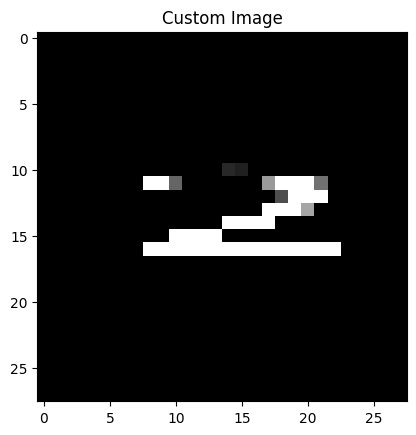

In [0]:
plt.imshow(img_array.reshape(28,28),cmap='gray')
plt.title("Custom Image")
plt.show()

In [0]:
model.save("mnist_cnn_model.h5")

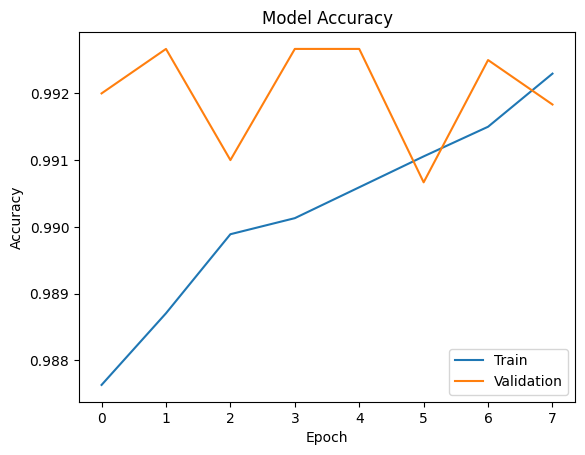

In [0]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Model Accuracy')

plt.ylabel('Accuracy')

plt.xlabel('Epoch')

plt.legend(['Train','Validation'])

plt.show()